In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from natsort import natsorted
from alntk.alignment import Alignment, find_sequence, write_to_fasta
from alntk.sector import highlight_sector

In [2]:
alphabet_aa = ['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y']

# Check the Red Sector of the alignment

*Written by Shoichi Yip. Last updated: 11 August 2026.*

Sectors are sets of residues that co-evolve nearly independently. The **red sector**, in particular, is believed to have an important role in determining specificity.

In [3]:
num = np.loadtxt("../data/iter_aln_v2_numbering.txt", dtype=str)
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)

These are the integer indices of the residues that are part of the red sector, in order of *relevance*.

In [4]:
red_sector

array([243, 201, 241, 228, 229, 204, 192, 189, 193, 165,   2, 242, 233,
       235, 198, 197, 177])

These are the corresponding labels of the red sector residues, always in order of *relevance*.

In [5]:
num[red_sector]

array(['228', '189', '226', '215', '216', '192', '183', '180', '184',
       '160', '18', '227', '219', '221', '188a', '188', '172'],
      dtype='<U4')

We can then also sort the residues *naturally*.

In [6]:
np.array(natsorted(num[red_sector]))

array(['18', '160', '172', '180', '183', '184', '188', '188a', '189',
       '192', '215', '216', '219', '221', '226', '227', '228'],
      dtype='<U4')

We can format it as a pyMol string.

In [7]:
'+'.join(natsorted(num[red_sector]))

'18+160+172+180+183+184+188+188a+189+192+215+216+219+221+226+227+228'

In this alingment (`iter_aln_v2.faa`) the `pySCA` code gives us a red sector made of 17 residues. They are mostly found in the C-terminus part of the protein sequences, with the exception of residue 18. In decreasing order of importance, they are the following residues:

`18+160+172+180+183+184+188+188a+189+192+215+216+219+221+226+227+228`

In [8]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [9]:
highlight_sector(aln, "P00763", red_sector, num, width=50)

16        26        36        42        52        
IVGGYTCQENSVPYQVSLNS------GYHFCGGSLINDQWVVSAAHCYKS

61a       67        76        86        96        
------RIQVRLGEHNIN-VLEGNEQFVNAAKIIKHPNFDR--KTLNNDI

104       114       123       131       140       
MLIKLSSPVKLNARVATV-ALPS---SCAP-AG-TQCLISGWGNTLSSG-

147       155       165       173b      181       
----VNEPDLLQCLDAPLLPQADCEASYP----GKITDNMVCVGFLEGG-

188A      198       207       217       225       
KDSCQGDSGGPVVCN-----GELQGIVSWGY--GCALPDNPGVYTKVCNY

235       245  
VDWIQDTIAAN----



In [10]:
highlight_sector(aln, "P00766", red_sector, num, width=50)

16        26        36        42        52        
IVNGEEAVPGSWPWQVSLQDK----TGFHFCGGSLINENWVVTAAHCGVT

61a       67        76        86        96        
-----TSDVVVAGEFDQG-SSSEKIQKLKIAKVFKNSKYNS--LTINNDI

104       114       123       131       140       
TLLKLSTAASFSQTVSAVC-LPSAS--DDFAAG-TTCVTTGWGLT-RY--

147       155       165       173b      181       
TNA--NTPDRLQQASLPLLSNTNCKKYWG----TKIKDAMICAGASGV--

188A      198       207       217       225       
-SSCMGDSGGPLVCKKN-GAWTLVGIVSWGSS-TCSTS-TPGVYARVTAL

235       245  
VNWVQQTLAAN----



## Comparison of red and green sectors to DMS data

In [11]:
rat_trypsin_nongapped_indices = np.where(find_sequence(aln, "P00763") != "-")[0]

In [12]:
dms_rat_trypsin = np.load("../data/dms_rat_trypsin.npy")
dms_ma = np.ma.array(dms_rat_trypsin, mask=np.isnan(dms_rat_trypsin))

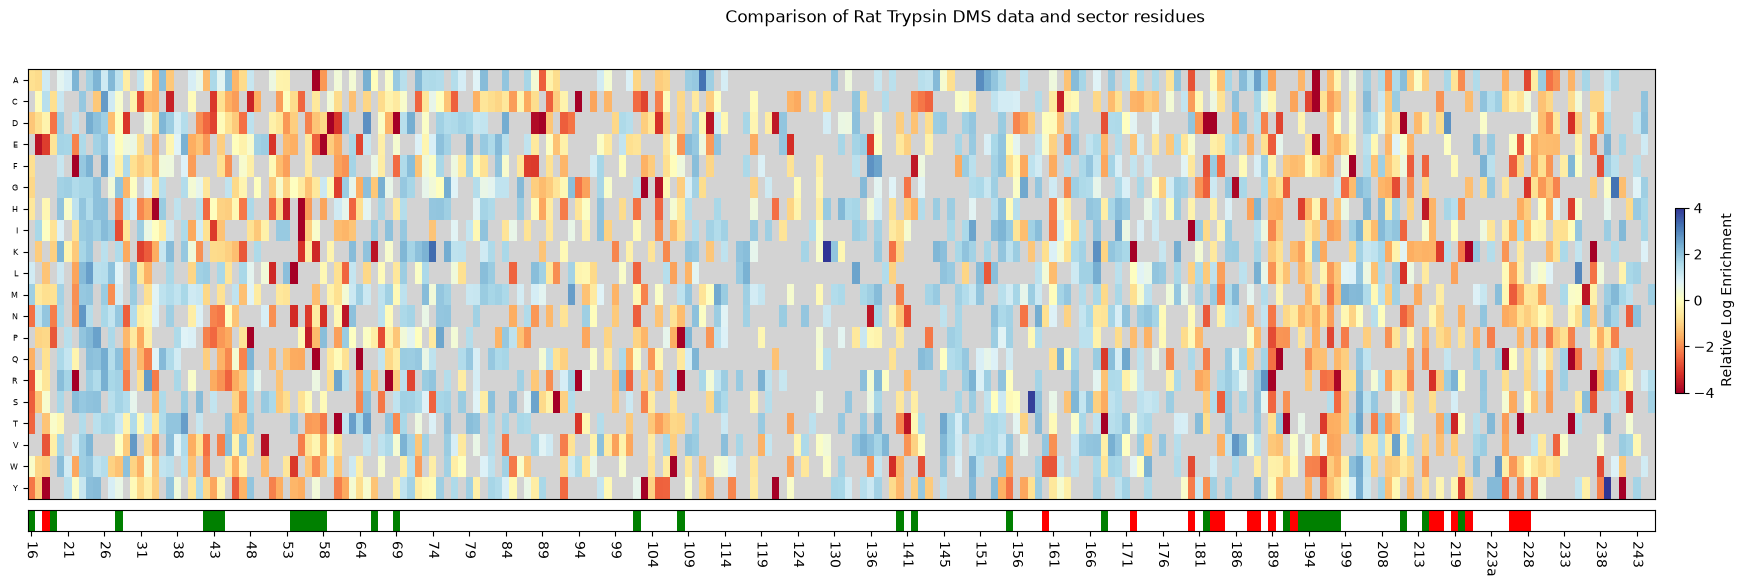

In [13]:
green_sector = np.loadtxt(
    "../data/iter_aln_v2_greensector.txt"
).astype(int)

green_sector_set = set(green_sector)
red_sector_set = set(red_sector)

green_sector_binary = np.array([
    r in green_sector_set
    for r in rat_trypsin_nongapped_indices
]).astype(int)

red_sector_binary = np.array([
    r in red_sector_set
    for r in rat_trypsin_nongapped_indices
]).astype(int)

assert green_sector_binary.size == dms_ma.shape[1]
assert red_sector_binary.size == dms_ma.shape[1]

# 0 = neither, 1 = green sector, 2 = red sector
annotation = np.zeros(dms_ma.shape[1], dtype=int)
annotation[green_sector_binary == 1] = 1
annotation[red_sector_binary == 1] = 2

one_line = annotation[np.newaxis, :]

annotation_cmap = ListedColormap([
    "white",
    "green",
    "red"
])

cmap = cm.RdYlBu.copy()
cmap.set_bad("lightgrey", 1.)

labels = np.asarray(num[rat_trypsin_nongapped_indices])
keep = np.arange(0, len(labels), 5)

nrows, ncols = dms_ma.shape

fig, (ax_main, ax_line) = plt.subplots(
    2,
    1,
    figsize=(25, 6),
    sharex=True,
    gridspec_kw={
        "height_ratios": [nrows, 1],
        "hspace": 0.05
    }
)

# Main heatmap
dms_heatmap = ax_main.imshow(
    dms_ma,
    cmap=cmap,
    vmin=-4.,
    vmax=+4.,
    aspect="auto",
    interpolation="nearest",
    extent=(-0.5, ncols - 0.5, nrows - 0.5, -0.5)
)

# Attach the colorbar to both axes so they retain the same width
fig.colorbar(
    dms_heatmap,
    ax=[ax_main, ax_line],
    shrink=0.4,
    pad=0.01,
    label="Relative Log Enrichment"
)

# Main heatmap y-axis
ax_main.set_yticks(np.arange(len(alphabet_aa)))
ax_main.set_yticklabels(alphabet_aa, size=6)

# Hide x labels on the upper heatmap
ax_main.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False
)

# Green-sector annotation heatmap
ax_line.imshow(
    one_line,
    cmap=annotation_cmap,
    vmin=0,
    vmax=2,
    aspect="auto",
    interpolation="nearest",
    extent=(-0.5, ncols - 0.5, 0, 1)
)

ax_line.set_yticks([])
ax_line.set_ylabel("")

ax_line.set_xticks(keep)
ax_line.set_xticklabels(
    labels[keep],
    rotation=-90
)

# Explicitly enforce identical x-limits
ax_main.set_xlim(-0.5, ncols - 0.5)
ax_line.set_xlim(-0.5, ncols - 0.5)

plt.suptitle("Comparison of Rat Trypsin DMS data and sector residues")

plt.show()

In [14]:
highlight_sector(aln, "P00763", green_sector, num, width=50, highlight_color="green")

16        26        36        42        52        
IVGGYTCQENSVPYQVSLNS------GYHFCGGSLINDQWVVSAAHCYKS

61a       67        76        86        96        
------RIQVRLGEHNIN-VLEGNEQFVNAAKIIKHPNFDR--KTLNNDI

104       114       123       131       140       
MLIKLSSPVKLNARVATV-ALPS---SCAP-AG-TQCLISGWGNTLSSG-

147       155       165       173b      181       
----VNEPDLLQCLDAPLLPQADCEASYP----GKITDNMVCVGFLEGG-

188A      198       207       217       225       
KDSCQGDSGGPVVCN-----GELQGIVSWGY--GCALPDNPGVYTKVCNY

235       245  
VDWIQDTIAAN----



In [15]:
highlight_sector(aln, "P00766", green_sector, num, width=50, highlight_color="green")

16        26        36        42        52        
IVNGEEAVPGSWPWQVSLQDK----TGFHFCGGSLINENWVVTAAHCGVT

61a       67        76        86        96        
-----TSDVVVAGEFDQG-SSSEKIQKLKIAKVFKNSKYNS--LTINNDI

104       114       123       131       140       
TLLKLSTAASFSQTVSAVC-LPSAS--DDFAAG-TTCVTTGWGLT-RY--

147       155       165       173b      181       
TNA--NTPDRLQQASLPLLSNTNCKKYWG----TKIKDAMICAGASGV--

188A      198       207       217       225       
-SSCMGDSGGPLVCKKN-GAWTLVGIVSWGSS-TCSTS-TPGVYARVTAL

235       245  
VNWVQQTLAAN----

